API Keys + LangSmith

In [2]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

In [3]:
os.environ["TAVILY_API_KEY"] = getpass.getpass("TAVILY_API_KEY")

In [4]:
from uuid import uuid4

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE7-S11-Certification-Challenge-{uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key: ")

Prepare PDF and Qdrant Database

In [5]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

path = 'data/'
loader = DirectoryLoader(path, glob='*.pdf', loader_cls=PyMuPDFLoader)
docs = loader.load()
print(f'Number of documents loaded: {len(docs)}')

Number of documents loaded: 25


chunking documents

In [6]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_documents = text_splitter.split_documents(docs)
print(f'Number of chunks generated: {len(split_documents)}')

Number of chunks generated: 52


Vectorization and in-memory Qdrant

In [7]:
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

embeddings = OpenAIEmbeddings(model='text-embedding-3-small')
client = QdrantClient(':memory:')
client.create_collection(
    collection_name='insurance_policy',
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)
vector_store = QdrantVectorStore(
    client=client,
    collection_name='insurance_policy',
    embedding=embeddings,
)
_ = vector_store.add_documents(documents=split_documents)
print('Vector store created and documents indexed.')

Vector store created and documents indexed.


Configure the retriever

In [8]:
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

In [9]:
def retrieve(state):
    retrieved_docs = retriever.invoke(state["question"])
    return {"context": retrieved_docs}

In [10]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on the provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

def generate(state):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
    response = llm.invoke(messages)
    return {"response": response.content}

In [12]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
    question: str
    context: List[Document]
    response: str

graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

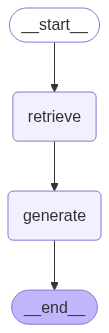

In [13]:
graph

In [14]:
response = graph.invoke({"question": "What is the UMR for my policy ?"})
print(response["response"])

The UMR for your policy is B1262SF0124814.


In [15]:
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage

@tool
def insurance_rag_tool(question: str) -> str:
	"""Useful for when you need to answer questions about insurance. Input should be a fully formed questions"""
	response = graph.invoke({"question": question})
	return {
		"messages": [HumanMessage(content=response["response"])],
		"context": response["context"]
}

ToolBelt

In [16]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

tavily_tool = TavilySearchResults(max_results=5)

tool_belt = [
    insurance_rag_tool,
    tavily_tool,
    ArxivQueryRun()
]

/tmp/ipykernel_8646/3190548365.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(max_results=5)


In [17]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4.1-nano", temperature=0)

In [18]:
model = model.bind_tools(tool_belt)

In [19]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
import operator
from langchain_core.messages import BaseMessage
from langchain_core.documents import Document

class AgentState(TypedDict):
  messages: Annotated[list, add_messages]
  context: List[Document]

In [37]:
from langgraph.prebuilt import ToolNode

def pre_rag_context(state: AgentState):
    question = state["messages"][-1].content
    print(f'The user question is : {question}')
    rag_result = graph.invoke({"question": question})
    print(f'The rag result is : {rag_result}')
    return {
        "messages": state["messages"],
        "context": rag_result["context"]  # Esto se pasa a `agent`
    }

def call_model(state):
    question_msg = state["messages"][-1]
    context_docs = state.get("context", [])
    
    docs_content = "\n\n".join(doc.page_content for doc in context_docs)

    # Usa el mismo prompt que en generate()
    messages = rag_prompt.format_messages(
        question=question_msg.content,
        context=docs_content
    )

    response = model.invoke(messages)

    return {
        "messages": [response],
        "context": context_docs
    }

tool_node = ToolNode(tool_belt)

In [38]:
from langgraph.graph import StateGraph, END

uncompiled_graph = StateGraph(AgentState)

uncompiled_graph.add_node("pre_rag_context", pre_rag_context)
uncompiled_graph.add_node("agent", call_model)
uncompiled_graph.add_node("action", tool_node)

In [39]:
uncompiled_graph.set_entry_point("pre_rag_context")
uncompiled_graph.add_edge("pre_rag_context", "agent")

In [40]:
def should_continue(state):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "action"

  return END

uncompiled_graph.add_conditional_edges(
    "agent",
    should_continue
)

In [41]:
uncompiled_graph.add_edge("action", "agent")

In [42]:

simple_agent_graph = uncompiled_graph.compile()

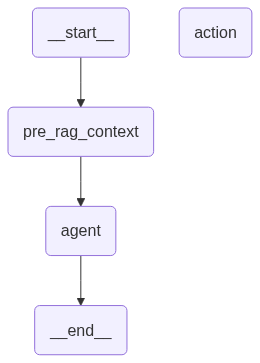

In [43]:
simple_agent_graph

In [46]:
from langchain_core.messages import HumanMessage

#inputs = {"messages" : [HumanMessage(content="What is the Unique Reference Market (UMR) for my policy ?")]}
inputs = {"messages" : [HumanMessage(content="Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?")]}

async for chunk in simple_agent_graph.astream(inputs, stream_mode="updates"):
    #print(f'chunk : {chunk}')
    for node, values in chunk.items():
        #print(f'node : {node} and values : {values}')
        print(f"Receiving update from node: '{node}'")
        print(values["messages"])
        print("\n\n")

The user question is : Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?
The rag result is : {'question': "Is the 'Institute Radioactive Contamination Exclusion Clause 10/11/03' still considered current industry standard in 2025?", 'context': [Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2015-08-07T17:35:36-04:00', 'source': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'file_path': 'data/F24716_AttachmentAExpiring1415PolicySoFComplete.pdf', 'total_pages': 25, 'format': 'PDF 1.6', 'title': 'REINSURANCE STANDARD SLIP - PART 1', 'author': 'Arthur J. Gallagher (UK) Ltd.', 'subject': '', 'keywords': '', 'moddate': '2015-08-07T17:36:28-04:00', 'trapped': '', 'modDate': "D:20150807173628-04'00'", 'creationDate': "D:20150807173536-04'00'", 'page': 14, '_id': '6339f74deb7d49d8871a3fb6914db0de', '_collection_name': 'insurance_policy'}, page_content